# CaF2 Post-Anneal

## Software Setup

In [2]:
## General purpose
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.axes as axes
import math
import scipy as sp
import datetime
import scipy.fft
import scipy.optimize as sp
import os
import time
import scipy.signal
import matplotlib.colors as cls
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import importlib
import pprint
from tqdm import tqdm
import glob
import re
from scipy import stats
import qcodes as qc
import sys
import qil_Visa.visa as visa
import pyvisa
from IPython.display import clear_output,display
import pyvisa
import TimeTagger
from windfreak import SynthHD

sys.path.append(r"C:\Users\Mario\Documents\GitHub\Drivers")
# Drivers
from unit_dmm.ut61eplus.ut61eplus import UT61EPLUS
from dlc_control.qil_DlcControl import dlccontrol as ctrl

# Helpers
import qil_helpers.Ben.LaserWrappers as ben
import qil_helpers.Fergus.magnet_helpers as ferg
import qil_helpers.Angela.sweeping as swp
import qil_helpers.Angela.switching as swtch
import qil_helpers.Angela.snspd as snshp
import qil_helpers.Angela.experimentHelpers as exhp
import qil_helpers.Tim.spectroscopyHelpers as sh
import qil_helpers.Tim.pulse_sequence as beeps
import qil_helpers.Tim.proHelpers as proHelp
import qil_helpers.Tim.laserHelpers as lhzz
import qil_helpers.Tim.plottingHelpers as plhp
import qil_helpers.Tim.plottingFunctions as plf
import drivers.pulse_sequence as beeps

In [2]:
# Various other functions
def getHistDataWrapped(hist, intTime=0.1):
    ps = 1e12                               # ps/s
    hist.startFor(intTime*ps, clear=True)   # run the histogram measurment for 5 seconds then get data. Clear removes old data before starting the measurement
    hist.waitUntilFinished()                # pause execution of python code until the measurement finished flag is true 
    data = hist.getData()                   # get data, of course 
    times = hist.getIndex()/ps              # time [s]
    return data, times

def test_histogram(intTime = 1, plot = 'lin'):
    data, times = getHistDataWrapped(intTime)
    laserFrequency = np.round(exhp.get_laser_frequency(wm, 20),6)
    if plot =='log':
        plt.semilogy(times*1e3, data, label= "Total Counts: " + str(sum(data)))              
    else:    
        plt.plot(times*1e3, data, label= "Total Counts: " + str(sum(data)))              
    plt.xlabel("Time (ms)")
    plt.title(str(laserFrequency) + ' THz, '+ str(intTime)+' s integration')              
    plt.legend()
#----------------------------------------------------------------------------#
def adjust_by_db(inputValue, gain):
    outputValue = inputValue * (10** (gain/10))

    return outputValue 
#----------------------------------------------------------------------------#
def cm2inch(*tupl):
    inch = 2.54
    if isinstance(tupl[0], tuple):
        return tuple(i/inch for i in tupl[0])
    else:
        return tuple(i/inch for i in tupl)
#----------------------------------------------------------------------------#
def setfontsize(size, ax):
    for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
        item.set_fontsize(size)
    return
#----------------------------------------------------------------------------#
def do_efficiency_measurement(measuredPower, windowTime, intTime, dutyCycle, gain):
    intTime = 2
    dutyCycle = 1
    windowTime = 0.1
    voltages = exhp.sweep_points(-0.75, -1.1, 0.005)
    biasCurrents = []
    totalCounts = []
    efficiencies = []

    power = measuredPower # measured in W

    frequency = exhp.get_laser_frequency(wm, 10)*1e12
    h = 6.626e-34
    ePerPhoton = h * frequency
    photonsPerSecond = power / ePerPhoton

    for i, voltage in enumerate(voltages):
        exhp.reset_detector(detectorOut, float(voltage))
        biasCurrents.append(exhp.get_detector_current(dmm))
        data, times = getHistDataWrapped(hist, intTime)
        totalCounts.append(sum(data))

        def countsToEffs(counts):
            countsPreOom = adjust_by_db(counts, gain) # 'amplifies' tt counts using OOM gain
            countsPerSecond = countsPreOom * windowTime/ (intTime * dutyCycle) # don't understand this line
            efficiency = 100*countsPerSecond/photonsPerSecond 
            return efficiency

        def effsToCounts(efficiency):
            countsPerSecond = efficiency*photonsPerSecond / 100
            countsPreOom=countsPerSecond* (intTime*dutyCycle) / windowTime
            counts = adjust_by_db(countsPreOom, -gain)
            return counts
        
        efficiencies.append(countsToEffs(sum(data)))
        numPhotons = adjust_by_db(photonsPerSecond, -gain)
        
        fig, ax = plt.subplots()
        fig.set_size_inches(cm2inch(20,12))
        ax.plot(biasCurrents, efficiencies)
        sec = ax.secondary_yaxis('right', functions=(effsToCounts, countsToEffs))

        ax.set_title("Efficiency vs i$_{bias}$, " +str(intTime)+"s Integration, "+str(round(numPhotons))+" Photons/s Exc")
        sec.set_ylabel("Counts")
        ax.set_ylabel('Efficiency (%)')
        # ax.set_ylim(0, 40)
        ax.set_xlabel("SSPD Bias Current ($\mu$A)")

        display(plt.gca())
        clear_output(wait=True)
        plt.show()
    
    exhp.reset_detector(detectorOut, -0.8)
    exhp.get_detector_current(dmm)

    fig, ax = plt.subplots()
    fig.set_size_inches(cm2inch(20,15))
    ax.plot(biasCurrents, efficiencies)
    sec = ax.secondary_yaxis('right', functions=(effsToCounts, countsToEffs))
    ax2 = ax.twiny()
    ax2.set_xlabel('Voltage (V)')
    ax2.plot(-voltages,efficiencies, 'C0')
    ax.set_title("Efficiency vs i$_{bias}$, " +str(intTime)+"s Integration, "+str(round(numPhotons))+" Photons/s Exc")
    sec.set_ylabel("Counts")
    ax.set_ylabel('Efficiency (%)')
    # ax.set_ylim(0, 40)
    ax.set_xlabel("SSPD Bias Current ($\mu$A)")

    display(plt.gca())
    clear_output(wait=True)
    plt.show()
    return (voltages, biasCurrents, totalCounts, efficiencies)   
#----------------------------------------------------------------------------#
def measure_dmm(dmm):
    meas = dmm.takeMeasurement()
    if not meas.overload:
        measurement  = meas.display
    else:
        measurement = -1
        print(f'WARNING: Check your sh*t')
    return measurement
#----------------------------------------------------------------------------#
def do_efficiency_measurement(detectorOut, unit, hist, wm, inputPower, countTimeRatio, voltageRange, voltageInt, runID, savePlot):
    ''' 
    Takes SNSPD efficiency measurement over bias current/voltage.

    ARGUMENTS (ignoring instruments)
    inputPower: optical power after attenuation
    countTimeRatio: ON/OFF time ratio for SNSPD trigger. depends on switching status
    voltageRange: [2x1 ARRAY] bias voltage range

    RETURNS 
    (voltages, biasCurrents, totalCounts, efficiencies), where length of each array depends on voltageRange and voltageInt
    '''

    intTime = 2
    dwell = 1
    voltages = swp.sweep_points(voltageRange[0], voltageRange[1], voltageInt)
    biasCurrents = np.zeros_like(voltages)
    totalCounts = np.zeros_like(voltages)
    countsPerSecond = np.zeros_like(voltages)
    efficiencies = np.zeros_like(voltages)
    
    # expDuration = datetime.timedelta(seconds = len(voltages) * (intTime + dwell))
    # print(fr'Experiment time ~ {str(expDuration)}')

    frequency = exhp.get_laser_frequency(wm, 1)*1e12 # Hz
    h = 6.62607015e-34
    ePerPhoton = h*frequency
    inputCounts = inputPower / ePerPhoton
    
    def normaliseCounts(measuredCounts, intTime, countTimeRatio):
        countsPerSecond =  measuredCounts / (intTime * countTimeRatio) 
        return countsPerSecond

    def countsToEffs(measuredCounts, intTime, countTimeRatio):
        countsPerSecond = normaliseCounts(measuredCounts, intTime, countTimeRatio) 
        efficiency = 100 * countsPerSecond / inputCounts 
        return efficiency
    
    for i, voltage in enumerate(tqdm(voltages)):
        exhp.reset_detector(detectorOut, voltage) # set bias
        time.sleep(dwell) # wait for 1s before taking measurement
        biasCurrents[i] = exhp.get_detector_current(dmm) * 1e6 # store as uA
        
        data, times = exhp.getHistDataWrapped(hist, intTime)
        totalCounts[i] = sum(data) # total counts over intTime = 2s
        countsPerSecond[i] = normaliseCounts(totalCounts[i], intTime, countTimeRatio) # counts per second
        efficiencies[i] = countsToEffs(sum(data), intTime, countTimeRatio)

        fig, ax = plt.subplots()
        fig.set_size_inches(plhp.cm2inch(20, 12))
        ax.plot(voltages, efficiencies)
        sec = ax.twinx()
        sec.plot(biasCurrents, countsPerSecond, alpha = 0)

        ax.set_title("Efficiency vs V$_{{bias}}$, " + str(intTime) + "s Integration, " + str(round(inputCounts)) + " Photons/s Exc")
        ax.set_xlabel("- SNSPD Bias Voltage (V))")
        sec.set_ylabel("Counts")
        ax.set_ylabel('Efficiency (%)')
        # ax.set_ylim(0, 40)

        display(plt.gca())
        clear_output(wait = True)
        plt.show()
    
    # reset detector once sweep is complete
    exhp.reset_detector(detectorOut, 0)
    measure_dmm(unit)

    # final plot
    fig, ax = plt.subplots()
    fig.set_size_inches(plhp.cm2inch(20, 15))
    ax.plot(voltages, efficiencies)
    sec = ax.twinx()
    sec.plot(voltages, countsPerSecond, alpha = 0)
    sec.set_ylabel(fr'Count Rate (s$^{-1}$)')
    ax2 = ax.twiny()
    ax2.set_xlabel('Voltage (V)')
    ax2.plot(biasCurrents, efficiencies, alpha = 0)
    ax.set_title("Efficiency vs i$_{{bias}}$, " + str(intTime) + "s Integration, " + str(round(inputCounts)) + " Photons/s Exc")
    sec.set_ylabel(f"Total Counts in {intTime} s")
    ax.set_ylabel('Efficiency (%)')
    # ax.set_ylim(0, 40)
    ax.set_xlabel("SNSPD Bias Current ($\mu$A)")

    display(plt.gca())
    clear_output(wait = True)
    plt.tight_layout()
    if savePlot == True:
        dateString = time.strftime('%Y-%m-%d')
        plotPath = fr'plots/{dateString}'
        os.makedirs(plotPath, exist_ok=True)
        plt.savefig(fr'{plotPath}/efficiency{runID}.jpg')
    plt.show()
    
    return (voltages, biasCurrents, totalCounts, efficiencies)

def do_dark_measurement(detectorOut, dmm, hist, voltageRange, voltageInt, intTime, countTimeRatio, runID, save = False):
    '''
    Basically same measurement as above. But make sure the laser is shuttered/there is no input.
    '''
    dwell = 1
    voltages = swp.sweep_points(voltageRange[0], voltageRange[1], voltageInt)
    biasCurrents = np.zeros_like(voltages)
    totalCounts = np.zeros_like(voltages)
    
    # expDuration = datetime.timedelta(seconds = len(voltages) * (intTime + dwell))
    # print(fr'Experiment time ~ {str(expDuration)}')

    for i, voltage in enumerate(tqdm(voltages)):
        exhp.reset_detector(detectorOut, voltage) # set bias
        time.sleep(dwell) # wait for 0.5s before taking measurement
        if dmm == unit:
            bias = measure_dmm(unit) # store as uA
        else:
            bias = exhp.get_detector_current(dmm)
        biasCurrents[i] = bias
        
        data, times = exhp.getHistDataWrapped(hist, intTime)
        totalCounts[i] = sum(data) # total counts over intTime = 2s

        fig, ax = plt.subplots()
        fig.set_size_inches(plhp.cm2inch(20, 12))
        ax.plot(voltages, totalCounts / (countTimeRatio * intTime), c = 'tab:blue')

        ax.set_title(fr"Dark Counts vs V$_{{bias}}$, " + str(intTime) + "s Integration")
        # ax.set_xlabel(r"SNSPD Bias Current ($\mu$A)")
        ax.set_xlabel(r"SNSPD Bias Voltage (V)")
        ax.set_ylabel(r"Dark Count Rate (s$^{-1}$)")

        display(plt.gca())
        clear_output(wait = True)
        plt.show()
    
    # reset detector after measurement
    exhp.reset_detector(detectorOut, 0)
    time.sleep(1)
    if dmm == unit:
        measure_dmm(unit) # store as uA
    else:
        exhp.get_detector_current(dmm)    
    return (voltages, biasCurrents, totalCounts)

def set_up_3_pulse_echo(pi2, pi, tau, countFor = 10, switchPreDelay = 3, nPoints = 5000, plotting = False, verbose = False, pi2Off = False, piOff = False):  

    '''
    ARGS:
    # pi2 - pi/2 pulse length
    # pi -
    # tau - remember HOW TAU IS DEFINED HERE
    # countFor - basically how long you want the SNSPD to count for. default to count for 10 us
    # switchPreDelay - moves the trigger back in time to account for switches taking a moment to ... switch. 
    #            be CAREFUL you might end up in the FID if you make this too long 
    # nPoints - the number of points - this defines the timing resolution with which we make the pulse sequence 
    '''

    # Easter egg - to make it so that the count time depends on pi pulse time
    if countFor == -1:
        countFor = 4*pi

    # Set up switch timings
    switchTimings = [pi2, tau, pi, tau, pi2, countFor]
    aomTimings = [pi2, tau, pi, tau, pi2, countFor]
    ttlTimings = [pi2 + tau + pi + tau + pi2, countFor]
    totalTime = sum(switchTimings) # Verify all sequences are the same duration
    snspdTimings = [totalTime - (countFor + switchPreDelay), countFor + switchPreDelay]
    period = totalTime
    
    if pi2Off:
        switchTimings = [pi2 + tau, pi, tau + pi2 + countFor]
        aomTimings = [pi2 + tau, pi, tau+pi2 + countFor]
            
    if piOff:
        switchTimings = [pi2, tau + pi + tau + pi2 + countFor]
        aomTimings = [pi2, tau + pi + tau+pi2 + countFor]

    if pi2Off & piOff:
        switchTimings = [pi2+ tau + pi + tau + pi2 + countFor]
        aomTimings = [pi2+ tau + pi + tau + pi2 + countFor]

    if verbose == True:
        print('calculated timings')
    
    aoms = beeps.pulse_sequence(aomTimings, startHigh=True, highVoltage=5, numPoints = nPoints, period=period)
    switch1 = beeps.pulse_sequence(switchTimings, startHigh=True, highVoltage=5, numPoints = nPoints, period =period)
    echoTTL = beeps.pulse_sequence(ttlTimings, startHigh=False, numPoints = nPoints, period = period)
    snspdBias = beeps.pulse_sequence(snspdTimings, highVoltage=3.5, startHigh=False, numPoints= nPoints, period = period)
    
    if piOff:
        aoms = beeps.pulse_sequence(aomTimings,startHigh=True, highVoltage=5, numPoints = nPoints, period=period)
        switch1 = beeps.pulse_sequence(switchTimings, startHigh=True, highVoltage=5, numPoints = nPoints, period =period)

    if pi2Off:
        aoms = beeps.pulse_sequence(aomTimings,startHigh=False, highVoltage=5, numPoints = nPoints, period=period)
        switch1 = beeps.pulse_sequence(switchTimings, startHigh=False, highVoltage=5, numPoints = nPoints, period =period)

    if verbose == True:
        print('generated sequences')

    packet = [aoms , switch1, echoTTL,  snspdBias]
    proChannels = [1,2,3,4]

    if not(plotting):
        proHelp.tell_awg(packet, proChannels, awg)
        if verbose ==True:
            print('told awg')

    if plotting:
        plt.figure(figsize = (12, 6))
        plt.fill_between(aoms.times, aoms.lookupTable, 
                         color = 'orange', alpha = 0.2)
        plt.plot(switch1.times, switch1.lookupTable,
                 c = 'red')
        plt.plot(echoTTL.times, echoTTL.lookupTable,
                 c = 'green')
        plt.plot(snspdBias.times,snspdBias.lookupTable,
                 c = 'blue')
        plt.legend(("aoms",
                    "switches", 
                    "echo TTL",
                    "snspd"))
        plt.xlabel('time (us)')
        plt.ylabel('switch state')
    return

def set_up_2_pulse_hole(pi2, pi, tau, countFor, switchPreDelay, nPoints = 5000, plotting = False, verbose = False, pi2Off = False, piOff = False):  
    '''
    ARGS:
    # pi2 - pi/2 pulse length
    # pi -
    # tau - remember HOW TAU IS DEFINED HERE
    # countFor - basically how long you want the SNSPD to count for. default to count for 10 us
    # switchPreDelay - moves the trigger back in time to account for switches taking a moment to ... switch. 
    #            be CAREFUL you might end up in the FID if you make this too long 
    # nPoints - the number of points - this defines the timing resolution with which we make the pulse sequence 
    '''

    # Easter egg - to make it so that the count time depends on pi pulse time
    if countFor == -1:
        countFor = 4*pi

    # Set up switch timings
    switchTimings = [pi2, tau, pi, countFor]
    aomTimings = [pi2, tau, pi, countFor]
    ttlTimings = [pi2 + tau + pi, countFor]
    totalTime = sum(switchTimings) # Verify all sequences are the same duration
    snspdTimings = [totalTime - (countFor + switchPreDelay), countFor + switchPreDelay]
    period = totalTime
    
    if pi2Off:
        switchTimings = [pi2 + tau, pi, countFor]
        aomTimings = [pi2 + tau, pi, countFor]
            
    if piOff:
        switchTimings = [pi2, tau + pi + countFor]
        aomTimings = [pi2, tau + pi + countFor]

    if pi2Off & piOff:
        switchTimings = [pi2+ tau + pi + countFor]
        aomTimings = [pi2+ tau + pi + countFor]

    if verbose == True:
        print('calculated timings')
    
    aoms = beeps.pulse_sequence(aomTimings, startHigh=True, highVoltage=5, numPoints = nPoints, period=period)
    switch1 = beeps.pulse_sequence(switchTimings, startHigh=True, highVoltage=5, numPoints = nPoints, period =period)
    echoTTL = beeps.pulse_sequence(ttlTimings, startHigh=False, numPoints = nPoints, period = period)
    snspdBias = beeps.pulse_sequence(snspdTimings, highVoltage=3.5, startHigh=False, numPoints= nPoints, period = period)
    
    if piOff:
        aoms = beeps.pulse_sequence(aomTimings,startHigh=True, highVoltage=5, numPoints = nPoints, period=period)
        switch1 = beeps.pulse_sequence(switchTimings, startHigh=True, highVoltage=5, numPoints = nPoints, period =period)

    if pi2Off:
        aoms = beeps.pulse_sequence(aomTimings,startHigh=False, highVoltage=5, numPoints = nPoints, period=period)
        switch1 = beeps.pulse_sequence(switchTimings, startHigh=False, highVoltage=5, numPoints = nPoints, period =period)

    if verbose == True:
        print('generated sequences')

    packet = [aoms , switch1, echoTTL,  snspdBias]
    proChannels = [1,2,3,4]

    if not(plotting):
        proHelp.tell_awg(packet, proChannels, awg)
        if verbose ==True:
            print('told awg')

    if plotting:
        plt.figure(figsize = (12, 6))
        plt.fill_between(aoms.times, aoms.lookupTable, 
                        color = 'orange', alpha = 0.2)
        plt.plot(switch1.times, switch1.lookupTable,
                c = 'red')
        plt.plot(echoTTL.times, echoTTL.lookupTable,
                c = 'green')
        plt.plot(snspdBias.times,snspdBias.lookupTable,
                c = 'blue')
        plt.legend(("aoms",
                    "switches", 
                    "echo TTL",
                    "snspd"))
        plt.xlabel('time (us)')
        plt.ylabel('switch state')
    return

def all_off(awg, snspd = False, plotting = True):  
    nPoints = 5000
    switchTimings = [100]
    aomTimings = [100]
    ttlTimings = [100]
    snspdTiming = [100]  

    switches = beeps.pulse_sequence(switchTimings, highVoltage = 5, startHigh = False, numPoints = nPoints)
    AOMs = beeps.pulse_sequence(aomTimings, highVoltage = 5, startHigh = False, numPoints = nPoints)
    echoTTL = beeps.pulse_sequence(ttlTimings, startHigh = False, numPoints = nPoints)
    snspdBias = beeps.pulse_sequence(snspdTiming, highVoltage = 3, startHigh = False, numPoints = nPoints)

    packet = [AOMs, switches, echoTTL, snspdBias]
    proChannels = [1,2,3,4]

    if not(plotting):
        proHelp.tell_awg(packet, proChannels, awg)
        for channel in proChannels:
            awg.disable_modulation(channel)

    if plotting:
        plt.plot(AOMs.times, AOMs.lookupTable, linewidth = 10)
        plt.plot(switches.times, switches.lookupTable, linewidth = 5)
        plt.plot(echoTTL.times, echoTTL.lookupTable)
        plt.plot(snspdBias.times,snspdBias.lookupTable)
        plt.legend(("AOMs",
                    "switches", 
                    # "switch 2", 
                    # "VOA", 
                    "echo TTL",
                    "snspd"))
    return

def PLE_data_collect(
     description,
     sweep: swp.timTam_config,
     switch: swtch.PLE_switch_config,
     tt,
     aom_frequency, # GHz
     attocube,
     axis,
     magnet = None,
     extra_params = None,
     save_path = None):

    timestamp = datetime.datetime.now()
    timestring = timestamp.strftime("%Y-%m-%d_%H-%M-%S")

    data = {
        # Run information and ID
        "Description": description,
        "Run ID": sweep.run_id,
        "Timestamp": timestring,

        # Switch parameters
        "Excitation Time (ms)": switch.exc_time/1e3,
        "Count Time (ms)": switch.count_time/1e3,
        "Dead Cycle": switch.dead_cycle,
        "AOMs (GHz)": aom_frequency,

        # Measurement parameters
        "Dead Time (ps)": tt.dead_time,
        "Integration Time (s)": sweep.int_time,
        "Bin Width (us)": tt.bin_width*1e6,
        "Number of Bins": tt.n_bins,
        "Trigger Level (V)": tt.trigger_level,
        "Bias (V)": sweep.bias,

        # Laser sweep parameters
        "Laser Amplitude (mA)": sweep.laser_amplitude,
        "Piezo Centre (V)": sweep.piezo_centre,
        "Scan Half Range (V)": sweep.scan_half,
        "Num Steps": sweep.num_steps,
        "Wavelength centres (nm)": sweep.wavelengths,

        # Record attocube position
        "Attocube Position (nm)": float(attocube.control.getPositionsAndVoltages()[axis])
    }

    # Magnet
    if magnet is not None:
        data.update(AMI_data_collect(magnet, None))

    if extra_params is not None:
        data.update(extra_params)
    
    data_df = pd.DataFrame([data])
    data_df = data_df.T

    if save_path is None:
        save_path = r'C:\Users\Mario\Documents\GitHub\longterm_sweeps\data\experiment_log'
        os.makedirs(save_path, exist_ok = True)
        filename = f"{timestring}_{sweep.run_id}.csv"
        data_df.to_csv(os.path.join(save_path, filename), index = True)

    if save_path is not None:
        os.makedirs(save_path, exist_ok = True)
        filename = f"{timestring}_{sweep.run_id}.csv"
        data_df.to_csv(os.path.join(save_path, filename), index = True)
        
    return data_df

## Hardware Setup

In [3]:
### Always Instruments

### Toptica Laser
from toptica.lasersdk.dlcpro.v2_2_0 import DLCpro, NetworkConnection  
laserIP = '10.196.50.22'
timTam = ben.laser_TT(laserIP, 0.1)

### Wavemeter
from qil_WS6wavemeter import TCP_Wavemeter
try:
    wm = TCP_Wavemeter.cWS6WavemeterClient(host = 'qil-wario.research.sydney.edu.au')
    print("Wavemeter frequency: ", wm.readFrequency())
except KeyError:
    print("Key error returned - wavemeter probably not seeing enough light.")

### Stahl power supply
from qcodes.instrument_drivers.rigol import DP832
from qcodes.instrument_drivers.stahl import Stahl
stahl = Stahl("stahl-9", "ASRL4")       
detectorOut = stahl.channel8            

### Moku AWG
import moku

### For the Moku Pro
from moku.instruments import ArbitraryWaveformGenerator
mokuIP = '10.196.50.45' # Sydnet6 IP for Moku Pro
awg = ArbitraryWaveformGenerator(mokuIP, force_connect=True, persist_state=True, read_timeout=30)

### For Bluey
import json 
import requests

# ### Keithley DMM
# import qcodes.instrument_drivers.tektronix.Keithley_6500 as dmm6500
# dmm = dmm6500.Keithley_6500('dmm','TCPIP::10.196.50.27::INSTR')

### UNI-T dmm
unit = UT61EPLUS()

### Rigol oscilloscope 
from qil_Rigol.rigol import cRigol 
scope = cRigol('10.196.50.21') # IP address of Rigol MSO5104 on the gantry is: 10.196.50.21. verify connection here.

c:\Users\Mario\.conda\envs\qcodes_env\lib\site-packages\qcodes\instrument\instrument_base.py:642: UserWarning: Changed stahl-9 to stahl_9 for instrument identifier
  warnings.warn(f"Changed {name} to {new_name} for instrument identifier")
[stahl_9(Stahl)] Could not connect at ASRL4
Traceback (most recent call last):
  File "c:\Users\Mario\.conda\envs\qcodes_env\lib\site-packages\qcodes\instrument\visa.py", line 215, in _connect_and_handle_error
    visa_handle, visabackend, resource_manager = self._open_resource(
  File "c:\Users\Mario\.conda\envs\qcodes_env\lib\site-packages\qcodes\instrument\visa.py", line 243, in _open_resource
    resource = resource_manager.open_resource(address)
  File "c:\Users\Mario\.conda\envs\qcodes_env\lib\site-packages\pyvisa\highlevel.py", line 3304, in open_resource
    res.open(access_mode, open_timeout)
  File "c:\Users\Mario\.conda\envs\qcodes_env\lib\site-packages\pyvisa\resources\resource.py", line 297, in open
    self.session, status = self._resour

Importing Functions
Key error returned - wavemeter probably not seeing enough light.


VisaIOError: VI_ERROR_RSRC_BUSY (-1073807246): The resource is valid, but VISA cannot currently access it.

In [4]:
### American magnetics power supply
from qcodes.instrument_drivers.american_magnetics.AMI430_visa import AMI430
iz = AMI430('z', address = "TCPIP0::10.196.50.17::7180::SOCKET") # connnect to z-axis
iz.add_parameter("get_vs", 
                 get_cmd ='VOLT:SUPP?', 
                 get_parser = float)
iz.add_parameter("get_cs", 
                 get_cmd ='CURR:SUPP?', 
                 get_parser = float) 

C:\Users\Mario\AppData\Local\Temp\ipykernel_12036\4276116187.py:3: QCoDeSDeprecationWarning: Use qcodes.instrument_drivers.american_magnetics.AMIModel430 instead.
  iz = AMI430('z', address = "TCPIP0::10.196.50.17::7180::SOCKET") # connnect to z-axis
[z(AMI430)] Could not connect at TCPIP0::10.196.50.17::7180::SOCKET
Traceback (most recent call last):
  File "c:\Users\Mario\.conda\envs\qcodes_env\lib\site-packages\qcodes\instrument\visa.py", line 215, in _connect_and_handle_error
    visa_handle, visabackend, resource_manager = self._open_resource(
  File "c:\Users\Mario\.conda\envs\qcodes_env\lib\site-packages\qcodes\instrument\visa.py", line 243, in _open_resource
    resource = resource_manager.open_resource(address)
  File "c:\Users\Mario\.conda\envs\qcodes_env\lib\site-packages\pyvisa\highlevel.py", line 3304, in open_resource
    res.open(access_mode, open_timeout)
  File "c:\Users\Mario\.conda\envs\qcodes_env\lib\site-packages\pyvisa\resources\resource.py", line 297, in open
   

VisaIOError: VI_ERROR_RSRC_NFOUND (-1073807343): Insufficient location information or the requested device or resource is not present in the system.

In [4]:
### Attocube
import qil_attocube
amc = qil_attocube.Device('10.196.50.26')
amc.connect()

## Free Instruments

In [9]:
swtch.all_on(awg)

In [ ]:
all_off(awg)

In [104]:
exhp.reset_detector(detectorOut, 0)
time.sleep(1)
exhp.reset_detector(detectorOut, -0.85)
# measure_dmm(unit)

-0.85

In [ ]:
stahl.close()

In [5]:
dmm.close()

NameError: name 'dmm' is not defined

In [ ]:
iz.close()

In [103]:
import TimeTagger
tt = TimeTagger.createTimeTagger()
TimeTagger.freeTimeTagger(tt)
tt

<TimeTagger.TimeTagger; proxy of None >

## Diagnostics

### Test Histogram

cycleTime: 93.0 ms


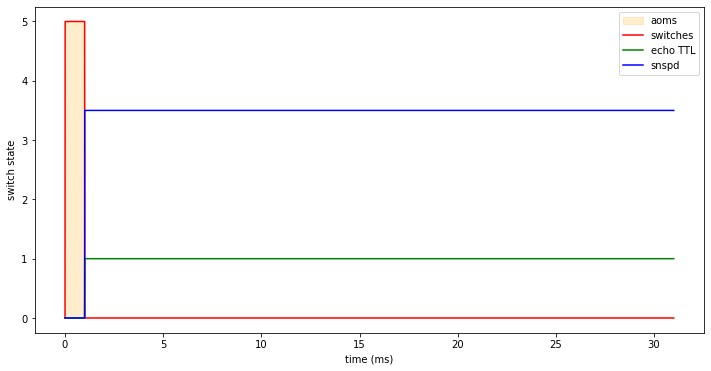

In [6]:
# SET UP AND APPLY SWITCHING PARAMETERS
switch = swtch.PLE_switch_config(
    exc_time = 1e3, # us
    count_time = 30e3, # us
    dead_cycle = 2
)

swtch.PLE_switch_config.apply(switch, awg, test = False)
print(f'cycleTime: {((switch.exc_time + switch.count_time) * (switch.dead_cycle + 1))/1e3} ms')

In [89]:
# SET UP AND APPLY TIMETAGGER PARAMETERS
tt_config = swtch.PLE_tt_config(
    dead_time = 0.01e-9, # s
    trigger_level = 0.042, # V
    bin_width = 500e-6, # s
    n_bins = 120
)

# hist = swtch.PLE_tt_config.apply(tt_config) 

ps = 1e12 
binwidth = 120e-6 * ps  # s
n_bins = 500 # number of bins

tt = TimeTagger.createTimeTagger()
hist = TimeTagger.Histogram(tagger = tt,
                             start_channel = 2, 
                             click_channel = 1, 
                             binwidth = tt_config.bin_width * ps, 
                             n_bins = tt_config.n_bins,
                             )

tt.setTriggerLevel(2, 0.25) # starts channel trigger level = 250 mV (signal is 500 mV)
tt.setDeadtime(2, tt_config.dead_time * ps) # starts channel trigger level = 250 mV (signal is 500 mV)
tt.setTriggerLevel(1, tt_config.trigger_level) # click channel trigger level = 42 mV

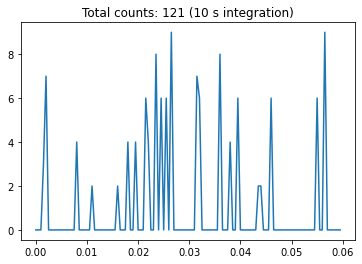

In [91]:
# TEST HISTOGRAM
intTime = 10
exhp.reset_detector(detectorOut, -0.85)
counts, bins = getHistDataWrapped(hist, intTime = intTime)
plt.plot(bins, counts)
plt.title(fr'Total counts: {np.sum(counts)} ({intTime} s integration)')
plt.show()

# Mysterious G1 Investigation

cycleTime: 93.0 ms


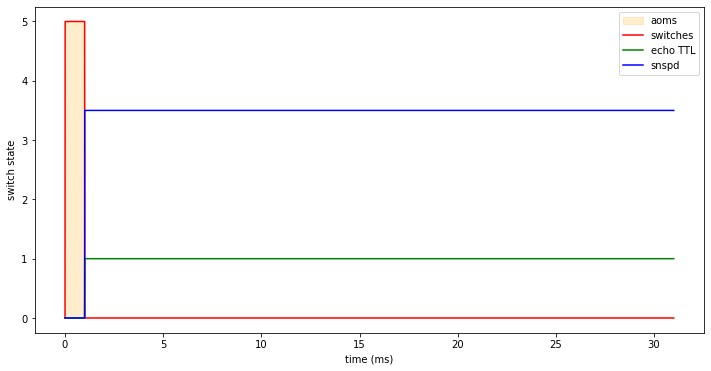

In [10]:
nShots = 20
ps = 1e12 
c = 299792458

# SET UP SWEEP PARAMETERS
sweep = swp.timTam_config(
    run_id = 'g1',
    wavelengths = lhzz.get_laser_wavelength(laserIP),
    piezo_centre = lhzz.get_piezo_center(laserIP),
    scan_half = 0,
    num_steps = 1,
    bias = -0.85,
    int_time = 55,
    laser_amplitude = 110,
)

# SET UP AND APPLY SWITCH PARAMETERS
switch = swtch.PLE_switch_config(
    exc_time = 1e3, # us
    count_time = 30e3, # us
    dead_cycle = 2
)

swtch.PLE_switch_config.apply(switch, awg, test = False)
print(f'cycleTime: {((switch.exc_time + switch.count_time) * (switch.dead_cycle + 1))/1e3} ms')

# SET UP AND APPLY TIMETAGGER PARAMETERS
tt_config = swtch.PLE_tt_config(
    dead_time = 0.01e-9, # s
    trigger_level = 0.042, # V
    bin_width = 500e-6, # s
    n_bins = 120
)

# hist = swtch.PLE_tt_config.apply(tt_config) 
tt = TimeTagger.createTimeTagger()
hist = TimeTagger.Histogram(tagger = tt,
                             start_channel = 2, 
                             click_channel = 1, 
                             binwidth = tt_config.bin_width * ps, 
                             n_bins = tt_config.n_bins,
                             )

tt.setTriggerLevel(2, 0.25) # starts channel trigger level = 250 mV (signal is 500 mV)
tt.setDeadtime(2, tt_config.dead_time * ps) # starts channel trigger level = 250 mV (signal is 500 mV)
tt.setTriggerLevel(1, tt_config.trigger_level) # click channel trigger level = 42 mV

In [11]:
# SAVE METADATA
PLE_data_collect(
    description = 'G1 post anneal 100 shot investigation',
    sweep = sweep,
    switch = switch,
    tt = tt_config,
    aom_frequency = 380, 
    attocube = amc,
    axis = 0,
    save_path = r'C:\Users\Mario\Documents\GitHub\Angela Honours\experiment log'
)

,0
Description,G1 post anneal 100 shot investigation
Run ID,g1
Timestamp,2026-04-21_14-15-32
Excitation Time (ms),1.0
Count Time (ms),30.0
Dead Cycle,2
AOMs (GHz),380
Dead Time (ps),0.0
Integration Time (s),55
Bin Width (us),500.0


In [ ]:
datestring = time.strftime('%Y-%m-%d')
pathData  = fr'C:\Users\Mario\Documents\GitHub\Angela Honours\data raw\{datestring}'
pathPlots = fr'C:\Users\Mario\Documents\GitHub\Angela Honours\plots raw\{datestring}'
os.makedirs(pathData, exist_ok = True)
os.makedirs(pathPlots, exist_ok = True)

sweepID = 1

In [14]:
# MOTOR SCAN FOR LARGE SCALE STRUCTURE
lhzz.turn_laser_on(laserIP)
print(fr'Run {sweepID}')

# Savepath
subFolderData = pathData + "/" + f"run{sweepID}" + "/" # don't forget ending "/"
subFolderPlots = pathPlots + "/" + f"run{sweepID}" + "/"
os.makedirs(subFolderData, exist_ok = True)
os.makedirs(subFolderPlots, exist_ok = True)

# Measurement Parameters
intTime = sweep.int_time
bias = sweep.bias

try:
    for n in tqdm(range(nShots)):
        print(fr'{intTime} s integration at {bias} V bias')

        # set detector and get data
        exhp.reset_detector(detectorOut, bias, 
                            sleepTime = 0.1)
        freq = exhp.get_laser_frequency(wm, 10) # THz
        data, times = getHistDataWrapped(hist, intTime = intTime)      
        dataAndTime = np.array([times, data])
        exhp.reset_detector(detectorOut, 0, sleepTime = 0.1)
        
        # save data
        now = datetime.datetime.now()
        filename = now.strftime("%Y-%m-%d %H-%M-%S") + "_freq_" + str(np.round(freq*1e6)) + "_MHz" + fr"_shot_{n}"
        np.savetxt(subFolderData + filename + ".csv", dataAndTime, delimiter = ",")
        
        # plot data
        fig, ax = plt.subplots()
        ax.plot(times*1e3, data)
        ax.set_xlabel("Time (ms)")
        ax.set_ylabel(f"Counts ({int} s integration)")
        ax.set_title(str(np.round(freq*1e3, 3)) +" GHz")
        fig.savefig(subFolderPlots + filename + ".jpg")
        plt.close(fig)
        clear_output()

finally:
    exhp.reset_detector(detectorOut, 0)
    lhzz.turn_laser_off(laserIP)
    sweepID += 1

100%|██████████| 20/20 [18:31<00:00, 55.58s/it]


Laser is off


### Step + Scan

cycleTime: 93.0 ms


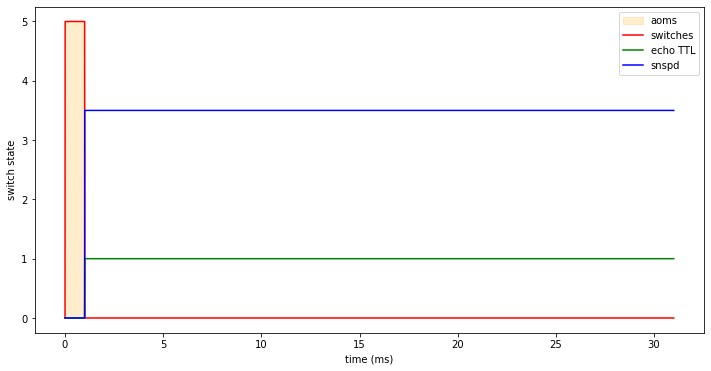

In [92]:
ps = 1e12 
c = 299792458

# SET UP SWEEP PARAMETERS
sweep = swp.timTam_config(
    run_id = 'g1 attocube scan',
    wavelengths = lhzz.get_laser_wavelength(laserIP),
    piezo_centre = lhzz.get_piezo_center(laserIP),
    scan_half = 70,
    num_steps = 10,
    bias = -0.85,
    int_time = 55,
    laser_amplitude = 110,
)

# SET UP AND APPLY SWITCH PARAMETERS
switch = swtch.PLE_switch_config(
    exc_time = 1e3, # us
    count_time = 30e3, # us
    dead_cycle = 2
)

swtch.PLE_switch_config.apply(switch, awg, test = False)
print(f'cycleTime: {((switch.exc_time + switch.count_time) * (switch.dead_cycle + 1))/1e3} ms')

# SET UP AND APPLY TIMETAGGER PARAMETERS
tt_config = swtch.PLE_tt_config(
    dead_time = 0.01e-9, # s
    trigger_level = 0.042, # V
    bin_width = 500e-6, # s
    n_bins = 120
)

# hist = swtch.PLE_tt_config.apply(tt_config) 
tt = TimeTagger.createTimeTagger()
hist = TimeTagger.Histogram(tagger = tt,
                             start_channel = 2, 
                             click_channel = 1, 
                             binwidth = tt_config.bin_width * ps, 
                             n_bins = tt_config.n_bins,
                             )

tt.setTriggerLevel(2, 0.25) # starts channel trigger level = 250 mV (signal is 500 mV)
tt.setDeadtime(2, tt_config.dead_time * ps) # starts channel trigger level = 250 mV (signal is 500 mV)
tt.setTriggerLevel(1, tt_config.trigger_level) # click channel trigger level = 42 mV

In [64]:
# ATTOCUBE
controlFreq = 1000 # Hz
controlVoltage = 30 # V

amc.control.setControlFrequency(0, controlFreq * 1e3) # mHz
amc.control.setControlAmplitude(0, controlVoltage * 1e3) # mV

print(fr'Axis 1 set to {amc.control.getControlAmplitude(0) / 1e3} V, {amc.control.getControlFrequency(0) / 1e3} Hz')
print(fr'Current position {amc.move.getPosition(0)/1e3} um')

Axis 1 set to 29.997 V, 999.982 Hz
Current position 1647.071185 um


In [96]:
steps = [5000, 2000, 1000, 1000, 2000, 2000]
wavelengths = [1512.14, 1514.7, 1517, 1517.5, 1518.25, 1519, 1520, 1522, 1525, 1530]

In [70]:
datestring = time.strftime('%Y-%m-%d')
pathData  = fr'C:\Users\Mario\Documents\GitHub\Angela Honours\data raw\{datestring}'
pathPlots = fr'C:\Users\Mario\Documents\GitHub\Angela Honours\plots raw\{datestring}'
os.makedirs(pathData, exist_ok = True)
os.makedirs(pathPlots, exist_ok = True)

sweepID = 1

In [74]:
now = datetime.datetime.now()
now.strftime("%Y-%m-%d %H-%M-%S")

'2026-04-22 10-48-38'

In [99]:
sweepID = 5

In [100]:
lhzz.turn_laser_on(laserIP)
print(fr'Run {sweepID}')

# Savepath
subFolderData = pathData + "/" + f"run{sweepID}" + "/" # don't forget ending "/"
subFolderPlots = pathPlots + "/" + f"run{sweepID}" + "/"
os.makedirs(subFolderData, exist_ok = True)
os.makedirs(subFolderPlots, exist_ok = True)

# Measurement Parameters
intTime = sweep.int_time
bias = sweep.bias

try:
    for nSteps in steps:
        position = amc.move.getPosition(0)
        print(fr'{position / 1e3} um')
        subSubFolderData = subFolderData + "/" + f"{position / 1e3 :.3f} um" + "/" # don't forget ending "/"
        subSubFolderPlots = subFolderPlots + "/" + f"{position / 1e3 :.3f} um" + "/"
        os.makedirs(subSubFolderData, exist_ok = True)
        os.makedirs(subSubFolderPlots, exist_ok = True)

        for wavelength in tqdm(wavelengths):
            # set up measurement parameters
            lhzz.set_piezo_center(laserIP, 70)
            lhzz.set_laser_wavelength(laserIP, wavelength)
            lhzz.set_piezo_amplitude(laserIP, 70)
            time.sleep(0.1)
            exhp.reset_detector(detectorOut, bias, sleepTime = 0.1)
            time.sleep(2)
            try:
                freq = exhp.get_laser_frequency(wm, 10) # THz
                tqdm.write(f"Wavemeter at {freq:.3f} THz")
            except: 
                freq = 0

            # start sweep
            data, times = getHistDataWrapped(hist, intTime = intTime)      
            dataAndTime = np.array([times, data])
            exhp.reset_detector(detectorOut, 0, sleepTime = 0.1)

            # save data
            now = datetime.datetime.now()
            # filename = f'now.strftime("%Y-%m-%d %H-%M-%S")_freq_{str(np.round(freq*1e6))}_MHz_{position/1e3}_um'
            filename = now.strftime("%Y-%m-%d %H-%M-%S") + "_freq_" + str(np.round(freq*1e6)) + "_MHz_" + f'{wavelength}_nm'
            np.savetxt(subSubFolderData + filename + ".csv", dataAndTime, delimiter = ",")

            # plot data
            fig, ax = plt.subplots()
            ax.plot(times*1e3, data)
            ax.set_xlabel("Time (ms)")
            ax.set_ylabel(f"Counts ({int} s integration)")
            ax.set_title(str(np.round(freq*1e3, 3)) +" GHz")
            fig.savefig(subSubFolderPlots + filename + ".jpg")
            # fig.savefig(subFolderPlots + filename + ".eps")
            plt.close(fig)
            clear_output()

        # move attocube
        amc.move.setNSteps(axis = 0, backward = True, step = nSteps)
        time.sleep(5)

finally:
    exhp.reset_detector(detectorOut, 0)
    lhzz.turn_laser_off(laserIP)
    sweepID += 1  


100%|██████████| 10/10 [09:46<00:00, 58.67s/it]


Laser is off


# Inhomogenenous Line

cycleTime: 93.0 ms


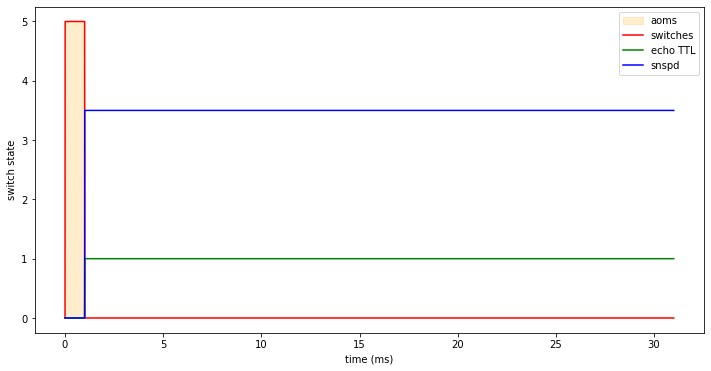

In [106]:
ps = 1e12 
c = 299792458

# SET UP SWEEP PARAMETERS
sweep = swp.timTam_config(
    run_id = 'g1 attocube scan',
    wavelengths = lhzz.get_laser_wavelength(laserIP),
    piezo_centre = lhzz.get_piezo_center(laserIP),
    scan_half = 0,
    num_steps = 850,
    bias = -0.85,
    int_time = 55,
    laser_amplitude = 110,
)

# SET UP AND APPLY SWITCH PARAMETERS
switch = swtch.PLE_switch_config(
    exc_time = 1e3, # us
    count_time = 30e3, # us
    dead_cycle = 2
)

swtch.PLE_switch_config.apply(switch, awg, test = False)
print(f'cycleTime: {((switch.exc_time + switch.count_time) * (switch.dead_cycle + 1))/1e3} ms')

# SET UP AND APPLY TIMETAGGER PARAMETERS
tt_config = swtch.PLE_tt_config(
    dead_time = 0.01e-9, # s
    trigger_level = 0.042, # V
    bin_width = 500e-6, # s
    n_bins = 120
)

# hist = swtch.PLE_tt_config.apply(tt_config) 
tt = TimeTagger.createTimeTagger()
hist = TimeTagger.Histogram(tagger = tt,
                             start_channel = 2, 
                             click_channel = 1, 
                             binwidth = tt_config.bin_width * ps, 
                             n_bins = tt_config.n_bins,
                             )

tt.setTriggerLevel(2, 0.25) # starts channel trigger level = 250 mV (signal is 500 mV)
tt.setDeadtime(2, tt_config.dead_time * ps) # starts channel trigger level = 250 mV (signal is 500 mV)
tt.setTriggerLevel(1, tt_config.trigger_level) # click channel trigger level = 42 mV

In [107]:
# SAVE METADATA
PLE_data_collect(
    description = 'caf_anneal_motor_run2',
    sweep = sweep,
    switch = switch,
    tt = tt_config,
    aom_frequency = 0.41, 
    attocube = amc,
    axis = 0,
    save_path = r'C:\Users\Mario\Documents\GitHub\Angela Honours\experiment log'
)

,0
Description,caf_anneal_motor_run2
Run ID,g1 attocube scan
Timestamp,2026-04-23_21-01-23
Excitation Time (ms),1.0
Count Time (ms),30.0
Dead Cycle,2
AOMs (GHz),0.41
Dead Time (ps),0.0
Integration Time (s),55
Bin Width (us),500.0


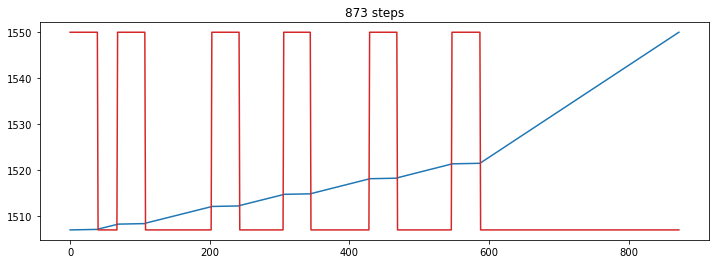

In [ ]:
# Design wavelength array such that scale is finer around sites
c = 299792458
span = 15e9 # 15 GHz total span at site
num_points = 40 # resolution at each site
site_waves = {}
vacant_waves = {}
vacant_wavelengths = []

freqs = {
    "cube_z1y1": 198.928e12,
    "b_z1y1": 198.762e12,
    "g1_z1y2": 198.257e12,
    "a_z1y2": 197.912e12,
    "g1_z1y1": 197.469e12,
    "a_z1y1": 197.049e12
}
sorted_sites = sorted(freqs.items(), key=lambda x: x[1])

# fine-scale scan around sites
for key, f0 in freqs.items():
    f_array = np.linspace(f0 - span/2, f0 + span/2, num_points)
    wave_array = c / f_array
    site_waves[key] = wave_array
site_cc = np.concatenate(list(site_waves.values()))

# broad scan elsewhere 
vacant_step = 5e9 # GHz
for i in range(len(sorted_sites) - 1):
    key_low, freq_low = sorted_sites[i]
    freq_low_max = freq_low + span
    key_high, freq_high = sorted_sites[i + 1]
    freq_high_min = freq_high - span
    vacant_freq = np.arange(freq_low_max, freq_high_min, vacant_step)
    vacant_wavelengths.append(c / vacant_freq)
vacant_cc = np.concatenate(vacant_wavelengths)

# concatenate and plot
long_wave = 1550e-9
original_wavelengths = np.concatenate([site_cc, vacant_cc])
longer_wavelengths = np.arange(np.max(original_wavelengths), long_wave, 0.1*1e-9)
wavelengths = np.concatenate([original_wavelengths, longer_wavelengths])
wavelengths = np.sort(wavelengths * 1e9)

idx = np.arange(0, len(wavelengths), 1)
plt.figure(figsize = (12, 4))
plt.plot(idx, wavelengths)
plt.title(fr'{len(wavelengths)} steps')

# to check range for piezo scan
site_intervals = []
for f0 in freqs.values():
    f_min = f0 - span/2
    f_max = f0 + span/2
    site_intervals.append((f_min, f_max))

# check logic for setting scan amplitude scan based on set wavelength
truth = np.zeros(len(wavelengths))
for i, wavelength in enumerate(wavelengths):
    f = c / (wavelength * 1e-9)
    in_site = any(f_min <= f <= f_max for (f_min, f_max) in site_intervals)
    if in_site:
        truth[i] = 1
    else:
        truth[i] = 0

plt.plot(idx, truth * (np.max(wavelengths) - np.min(wavelengths)) + np.min(wavelengths), c = 'tab:red')
plt.show()

In [138]:
datestring = time.strftime('%Y-%m-%d')
pathData  = fr'C:\Users\Mario\Documents\GitHub\Angela Honours\data raw\{datestring}'
pathPlots = fr'C:\Users\Mario\Documents\GitHub\Angela Honours\plots raw\{datestring}'
os.makedirs(pathData, exist_ok = True)
os.makedirs(pathPlots, exist_ok = True)

sweepID = 1

In [140]:
# MOTOR SCAN FOR LARGE SCALE STRUCTURE
lhzz.turn_laser_on(laserIP)
print(fr'Run {sweepID}')

# Savepath
subFolderData = pathData + "/" + f"run{sweepID}" + "/" # don't forget ending "/"
subFolderPlots = pathPlots + "/" + f"run{sweepID}" + "/"
os.makedirs(subFolderData, exist_ok = True)
os.makedirs(subFolderPlots, exist_ok = True)

# Measurement Parameters
intTime = sweep.int_time
bias = sweep.bias

try:
    for i, wavelength in enumerate(tqdm(wavelengths)):
        # set up measurement parameters
        lhzz.set_piezo_center(laserIP, 70)
        lhzz.set_laser_wavelength(laserIP, wavelength)
        time.sleep(0.1)
        exhp.reset_detector(detectorOut, bias, sleepTime = 0.1)
        time.sleep(0.7)
        freq = exhp.get_laser_frequency(wm, 10) # THz
        tqdm.write(f"Setting wavelength: {wavelength:.3f} nm at {freq:.3f} THz")
        
        # set scan amplitude scan based on set wavelength
        f = c / (wavelength * 1e-9)
        in_site = any(f_min <= f <= f_max for (f_min, f_max) in site_intervals)
        print(fr'In site? {in_site}')
        if in_site: # small scan range in site
            lhzz.set_piezo_amplitude(laserIP, 0.7)
        else: # large scan range outside site
            lhzz.set_piezo_amplitude(laserIP, 10)
        time.sleep(0.1)
        pzAmp = lhzz.get_piezo_amplitude(laserIP)
        print(fr'Piezo-voltage: {pzAmp} V')

        # start sweep
        data, times = getHistDataWrapped(hist, intTime = intTime)      
        dataAndTime = np.array([times, data])
        exhp.reset_detector(detectorOut, 0, sleepTime = 0.1)

        # save data
        now = datetime.datetime.now()
        filename = now.strftime("%Y-%m-%d %H-%M-%S") + "_freq_" + str(np.round(freq*1e6)) +"_MHz" + fr"_{pzAmp}_V" 
        np.savetxt(subFolderData + filename + ".csv", dataAndTime, delimiter = ",")

        # plot data
        fig, ax = plt.subplots()
        ax.plot(times*1e3, data)
        ax.set_xlabel("Time (ms)")
        ax.set_ylabel(f"Counts ({intTime} s integration)")
        ax.set_title(str(np.round(freq*1e3, 3)) +" GHz")
        fig.savefig(subFolderPlots + filename + ".jpg")
        # fig.savefig(subFolderPlots + filename + ".eps")
        plt.close(fig)

        clear_output()

finally:
    exhp.reset_detector(detectorOut, 0)
    lhzz.turn_laser_off(laserIP)
    sweepID += 1

100%|██████████| 873/873 [13:58:20<00:00, 57.62s/it]


Laser is off
